# SELLER PERFORMANCE

## BUSINESS ANALYSIS

1. Seller mana yang menghasilkan revenue tertinggi?
2. Bagaimana distribusi seller berdasarkan state?
3. Seller mana yang memiliki rata-rata waktu pengiriman tercepat?


## IMPORT LIBRARY

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import datetime

## GATHERING DATA

In [2]:
order = pd.read_csv('https://raw.githubusercontent.com/adinfir/data-new/refs/heads/main/E-commerce-public-dataset/orders_dataset.csv')
order_items = pd.read_csv('https://raw.githubusercontent.com/adinfir/data-new/refs/heads/main/E-commerce-public-dataset/order_items_dataset.csv')
seller = pd.read_csv('https://raw.githubusercontent.com/adinfir/data-new/refs/heads/main/E-commerce-public-dataset/sellers_dataset.csv')

## DATA UNDERSTANDING

In [3]:
order.head(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [4]:
order_items.head(5)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [5]:
seller.head(5)

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


### GRAIN

1. tabel order : 1 row merepresntasikan 1 order
2. tabel order_items : 1 row mempresentasikan item dalam sebuah order
3. tabel seller : 1 row mempresentasikan 1 seller

### KEY COLUMN

1. **Tabel `orders`**:
   - `order_id` → identifier untuk setiap order
   - `order_status` → status order
   - `order_purchase_timestamp` → waktu saat customer melakukan order
   - `order_delivered_customer_date` → waktu saat pelanggan menerima barang

2. **Tabel `order_items`**:
   - `order_id` → identifier order, digunakan untuk menghubungkan `order_items` dengan `orders`
   - `seller_id` → identifier seller, digunakan untuk menghubungkan `order_items` dengan `seller`
   - `price` → harga item

3. **Tabel `seller`**:
   - `seller_id` → identifier untuk setiap seller
   - `seller_state` → seller state

## QUALITY DATA

### ASESSING DATA

In [6]:
order.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


**DATA QUALITY NOTE**
1. Untuk kolom ```order_purchase_timestamp```,```order_approved_at```, ```order_delivered_carrier_date```, ```order_delivered_customer_date```,```order_estimated_delivery_date``` tipe data masih berbentuk object belum datetime

In [7]:
order.describe(include='all')

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2018-04-11 10:48:14,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-08 23:38:46,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [8]:
print('Checking null value')
order.isna().sum()

Checking null value


order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

**DATA QUALITY NOTE**
1.  Untuk kolom ```order_approved_at```, ```order_delivered_carrier_date```, ```order_delivered_customer_date``` terdapat missing value

In [9]:
print('Checking duplicated value')
order.duplicated().sum()

Checking duplicated value


0

In [10]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [11]:
order_items.describe(include='all')

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
count,112650,112650.000000,112650,112650,112650,112650.000000,112650.000000
unique,98666,NaN,32951,3095,93318,NaN,NaN
top,8272b63d03f5f79c56e9e4120aec44ef,NaN,aca2eb7d00ea1a7b8ebd4e68314663af,6560211a19b47992c3666cc44a7e94c0,2017-07-21 18:25:23,NaN,NaN
freq,21,NaN,527,2033,21,NaN,NaN
mean,NaN,1.197834,NaN,NaN,NaN,120.653739,19.990320
std,NaN,0.705124,NaN,NaN,NaN,183.633928,15.806405
min,NaN,1.000000,NaN,NaN,NaN,0.850000,0.000000
25%,NaN,1.000000,NaN,NaN,NaN,39.900000,13.080000
50%,NaN,1.000000,NaN,NaN,NaN,74.990000,16.260000
75%,NaN,1.000000,NaN,NaN,NaN,134.900000,21.150000


In [12]:
print('Checking null value')
order_items.isna().sum()

Checking null value


order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [13]:
print('Checking duplicated value')
order_items.duplicated().sum()

Checking duplicated value


0

In [14]:
seller.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


In [15]:
seller.describe(include='all')

,seller_id,seller_zip_code_prefix,seller_city,seller_state
count,3095,3095.000000,3095,3095
unique,3095,NaN,611,23
top,3442f8959a84dea7ee197c632cb2df15,NaN,sao paulo,SP
freq,1,NaN,694,1849
mean,NaN,32291.059451,NaN,NaN
std,NaN,32713.453830,NaN,NaN
min,NaN,1001.000000,NaN,NaN
25%,NaN,7093.500000,NaN,NaN
50%,NaN,14940.000000,NaN,NaN
75%,NaN,64552.500000,NaN,NaN


In [16]:
print('Checking null value')
seller.isna().sum()

Checking null value


seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

In [17]:
print('Checking duplicated value')
seller.duplicated().sum()

Checking duplicated value


0

### CLEANING DATA

## DATA PREPARATION 

### MENGUBAH TIPE DATA PADA TABEL ORDER

mengubah kolom ```order_purchase_timestamp```,```order_approved_at```, ```order_delivered_carrier_date```, ```order_delivered_customer_date```,```order_estimated_delivery_date``` menjadi daatetime

In [18]:
order['order_purchase_timestamp'] = pd.to_datetime(order['order_purchase_timestamp'])
order['order_approved_at'] = pd.to_datetime(order['order_approved_at'])
order['order_delivered_carrier_date'] = pd.to_datetime(order['order_delivered_carrier_date'])
order['order_delivered_customer_date'] = pd.to_datetime(order['order_delivered_customer_date'])
order['order_estimated_delivery_date'] = pd.to_datetime(order['order_estimated_delivery_date'])

### JOIN TABLE

In [19]:
#JOIN TABEL ORDER DAN ORDER_ITEMS
orders_items = pd.merge(
    left = order_items,
    right = order,
    how = 'left',
    on = 'order_id'
)

In [20]:
orders_items_seller = pd.merge(
    left = orders_items,
    right = seller,
    how = 'left',
    on = 'seller_id'
)

In [21]:
orders_items_seller.isna().sum()

order_id                            0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  15
order_delivered_carrier_date     1194
order_delivered_customer_date    2454
order_estimated_delivery_date       0
seller_zip_code_prefix              0
seller_city                         0
seller_state                        0
dtype: int64

**DATA QUALITY NOTE**

1. Terdapat missing value pada kolom `order_approved_at` sebanyak **15**, `order_delivered_carrier_date` sebanyak **1.194**, dan `order_delivered_customer_date` sebanyak **2.454**.

2. Missing value tidak dilakukan imputasi karena kolom tersebut merupakan timestamp proses order yang tidak dapat direkonstruksi secara valid dari data yang tersedia.

3. Untuk analisis **Q1 — Seller Revenue**, missing value pada timestamp tersebut tidak memengaruhi perhitungan karena revenue menggunakan `price`.

4. Untuk **Q3 — Seller Delivery Performance**, analisis dibatasi pada order dengan `order_status = 'delivered'` dan membutuhkan `order_delivered_customer_date`. Order yang tidak memiliki tanggal delivery aktual tidak dapat digunakan untuk menghitung waktu pengiriman.

5. Missing value pada timestamp proses order menjadi keterbatasan data yang perlu diperhatikan dalam analisis terkait proses dan durasi pengiriman.


In [22]:
## MENGAMBIL FEATURE UNTUK ANALISIS 
orders_items_seller = orders_items_seller[['order_item_id','product_id','order_id','price','seller_id','order_status','order_purchase_timestamp','order_delivered_customer_date','seller_state']]

In [23]:
orders_items_seller.duplicated().sum()

0

## EXPLORATORY DATA ANALYSIS

### 1. Seller mana yang menghasilkan revenue tertinggi?

In [24]:
seller_high_revenue = orders_items_seller[['order_item_id','product_id','seller_id','order_id','price','order_status']]

In [25]:
## MELAKUKAN FILTER ORDER_STATUS == DELIVERED
seller_high_revenue = seller_high_revenue[seller_high_revenue['order_status'] == 'delivered']

In [26]:
##CHECK DUPLICATE DATA
seller_high_revenue.duplicated().sum()

0

In [27]:
## MEMBUAT PIVOT TABLE 
seller_high_revenue_table = seller_high_revenue.groupby('seller_id').agg({
    'price' : 'sum',
    'order_id' : 'nunique',
}).reset_index()
seller_high_revenue_table

,seller_id,price,order_id
0,0015a82c2db000af6aaaf3ae2ecb0532,2685.00,3
1,001cca7ae9ae17fb1caed9dfb1094831,24487.03,195
2,002100f778ceb8431b7a1020ff7ab48f,1216.60,50
3,003554e2dce176b5555353e4f3555ac8,120.00,1
4,004c9cd9d87a3c30c522c48c4fc07416,19569.73,156
...,...,...,...
2965,ffc470761de7d0232558ba5e786e57b7,1529.13,27
2966,ffdd9f82b9a447f6f8d4b91554cc7dd3,2101.20,18
2967,ffeee66ac5d5a62fe688b9d26f83f534,1839.86,14
2968,fffd5413c0700ac820c7069d66d98c89,8535.00,57


In [28]:
#MENGGANTI NAMA KOLOM
seller_high_revenue_table = seller_high_revenue_table.rename(columns={
    'price': 'Total Revenue',
    'order_id' : 'Total Order'
    }
)

In [29]:
seller_high_revenue_table.sort_values(by='Total Revenue', ascending=False).head(10)

,seller_id,Total Revenue,Total Order
834,4869f7a5dfa277a7dca6462dcf3b52b2,226987.93,1124
982,53243585a1d6dc2643021fd1853d8905,217940.44,348
858,4a3ca9315b744ce9f8e9374361493884,196882.12,1772
2903,fa1c13f2614d7b5c4749cbc52fecda94,190917.14,578
1480,7c67e1448b00f6e969d365cea6b010ab,186570.05,973
1504,7e93a43ef30c4f03f38b393420bc753a,165981.49,319
2543,da8622b14eb17ae2831f4ac5b9dab84a,159816.87,1311
1450,7a67c85e85bb2ce8582c35f2203ad736,139658.69,1145
188,1025f0e2d44d7041d6cf58b6550e0bfa,138208.56,910
1758,955fee9216a65b617aa5c0531780ce60,131836.71,1261


C:\Users\adien\AppData\Local\Temp\ipykernel_14564\410675665.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


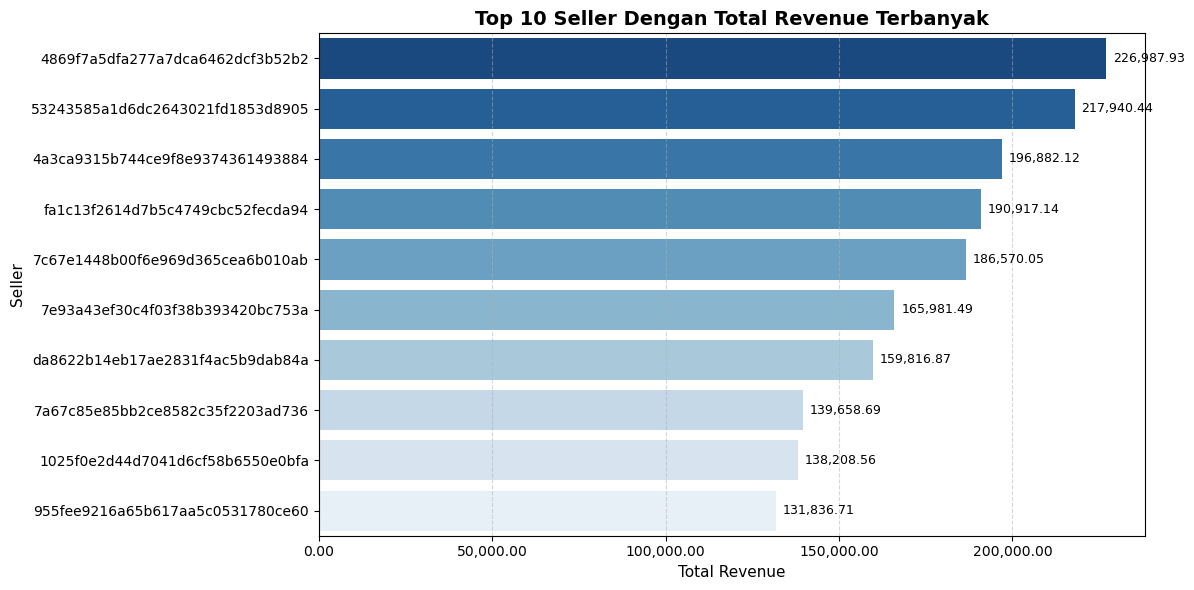

In [30]:
# 1. Ambil 10 data teratas (diurutkan dari terbesar)
# Sesuaikan 'Total Revenue' dan 'product_category_name' dengan nama kolom Anda
top_10_revenue_seller = seller_high_revenue_table.sort_values(by='Total Revenue', ascending=False).head(10)

# 2. Buat kanvas plot
plt.figure(figsize=(12, 6))

# 3. Membuat Horizontal Bar Plot
# (y = Nama Kategori, x = Nilai Angka)
ax = sns.barplot(
    data=top_10_revenue_seller,
    x='Total Revenue',            # Sumbu X (Angka)
    y='seller_id',   # Sumbu Y (Kategori)
    palette='Blues_r'            # Gradasi warna biru dari gelap ke terang (opsional)
)

# 4. Menambahkan Label Angka di Ujung Setiap Batang
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='{:,.2f}',               # Format koma pemisah ribuan
        padding=5,                   # Jarak teks dari batang
        fontsize=9
    )

# 5. Mengatasi format 1e6 pada sumbu X
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.2f}'))

# 6. Judul dan Label Sumbu
plt.title('Top 10 Seller Dengan Total Revenue Terbanyak', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue', fontsize=11)
plt.ylabel('Seller', fontsize=11)

# Garis grid horizontal dibuang, cukup beri garis grid vertical di sumbu X
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout() # Agar layout tidak terpotong saat disimpan/ditampilkan
plt.show()

#### KEY INSIGHT

1. seller dengan id ``4869f7a5dfa277a7dca6462dcf3b52b2`` memiliki total revenue tertinggi sebesar **226.987.93** dengan total order **1.124**.
2. seller dengan id ``53243585a1d6dc2643021fd1853d8905`` memiliki total revenue tertinggi kedua sebesar **217.940.44** dengan total order **348**.
3. Tingginya revenue tidak selalu diikuti oleh tingginya jumlah order, yang menunjukkan adanya perbedaan **nilai transaksi rata-rata antar-seller.**

### 2. Bagaimana distribusi seller berdasarkan state?

In [31]:
orders_items_seller.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 9 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_item_id                  112650 non-null  int64         
 1   product_id                     112650 non-null  object        
 2   order_id                       112650 non-null  object        
 3   price                          112650 non-null  float64       
 4   seller_id                      112650 non-null  object        
 5   order_status                   112650 non-null  object        
 6   order_purchase_timestamp       112650 non-null  datetime64[ns]
 7   order_delivered_customer_date  110196 non-null  datetime64[ns]
 8   seller_state                   112650 non-null  object        
dtypes: datetime64[ns](2), float64(1), int64(1), object(5)
memory usage: 7.7+ MB


In [32]:
distribution_seller = orders_items_seller[['seller_id', 'seller_state']]

In [33]:
##CHECK DUPLICATED
distribution_seller.duplicated().sum()

109555

**DATA QUALITY NOTE**

Setelah melakukan `LEFT JOIN` antara tabel `orders` dan `order_items`, ditemukan beberapa baris yang terlihat duplicated. Kondisi ini terjadi karena `order_id` yang sama dapat memiliki beberapa `order_item_id`, sedangkan `order_item_id` tidak disertakan dalam hasil data yang digunakan untuk analisis.

Karena Q2 hanya menganalisis **distribusi seller berdasarkan state**, informasi pada level item tidak diperlukan. Oleh karena itu, data yang duplicated pada level item tidak digunakan sebagai unit observasi dalam analisis ini.

In [34]:
## DROP DUPLICATED
distribution_seller.drop_duplicates(inplace=True)
distribution_seller.duplicated().sum()

C:\Users\adien\AppData\Local\Temp\ipykernel_14564\2016987602.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  distribution_seller.drop_duplicates(inplace=True)


0

In [35]:
distribution_state_seller = distribution_seller.groupby('seller_state')['seller_id'].nunique().reset_index()

In [36]:
#MENGGANTI NAMA KOLOM
distribution_state_seller = distribution_state_seller.rename(columns={
    'seller_state': 'State',
    'seller_id' : 'Jumlah Seller'
    }
)

In [37]:
distribution_state_seller.sort_values(by='Jumlah Seller', ascending=False)

,State,Jumlah Seller
22,SP,1849
15,PR,349
8,MG,244
20,SC,190
16,RJ,171
19,RS,129
6,GO,40
4,DF,30
5,ES,23
2,BA,19


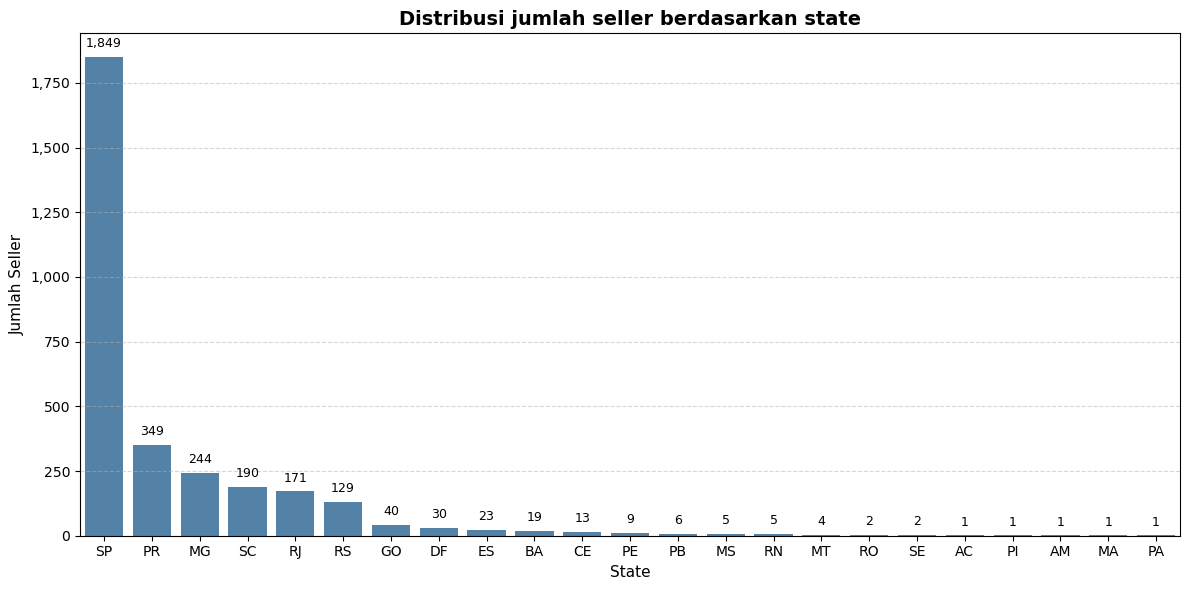

In [38]:
seller_state_desc = distribution_state_seller.sort_values(by = 'Jumlah Seller', ascending=False)
# Terapkan mapping ke kolom hari (pastikan ini dijalankan sebelum plot)
plt.figure(figsize=(12, 6))

# 2. Membuat Vertical Bar Plot
# Posisi x dan y ditukar
ax = sns.barplot(
    data=seller_state_desc,
    x='State',              # Sumbu X (Kategori / Nama Hari)
    y='Jumlah Seller',   # Sumbu Y (Angka)
    color='steelblue'      # Menggunakan satu warna solid, BUKAN gradien (palette)
)

# 3. Menambahkan Label Angka di Atas Setiap Batang
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='{:,.0f}',     
        padding=5,         
        fontsize=9
    )

# 4. Mengatasi format 1e6 pada sumbu Y (karena sumbu angka sekarang di Y)
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# 5. Judul dan Label Sumbu
plt.title('Distribusi jumlah seller berdasarkan state', fontsize=14, fontweight='bold')
plt.xlabel('State', fontsize=11)
plt.ylabel('Jumlah Seller', fontsize=11)

# 6. Grid disesuaikan menjadi horizontal (sumbu Y)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout() 
plt.show()

#### KEY INSIGHT

1. **State SP mempunyai jumlah seller terbanyak** sebanyak **1.849**
2. **State PR mempunyai jumlah seller terbanyak kedua** sebanyak **349**
3. Distribusi Seller **terkonsentrasi di beberapa state**, antara lain state SP yang memiliki jumlah seller terbanyak diantara state yang lain

### 3. Seller mana yang memiliki rata-rata waktu pengiriman tercepat?

In [39]:
orders_items_seller.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 9 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_item_id                  112650 non-null  int64         
 1   product_id                     112650 non-null  object        
 2   order_id                       112650 non-null  object        
 3   price                          112650 non-null  float64       
 4   seller_id                      112650 non-null  object        
 5   order_status                   112650 non-null  object        
 6   order_purchase_timestamp       112650 non-null  datetime64[ns]
 7   order_delivered_customer_date  110196 non-null  datetime64[ns]
 8   seller_state                   112650 non-null  object        
dtypes: datetime64[ns](2), float64(1), int64(1), object(5)
memory usage: 7.7+ MB


In [40]:
avg_delivery_time = orders_items_seller[['order_id','seller_id','order_status','order_purchase_timestamp','order_delivered_customer_date']]

In [41]:
## FILTER ORDER_STATUS = DELIVERED
avg_delivery_time = avg_delivery_time[avg_delivery_time['order_status'] == 'delivered']

In [42]:
print('Jumlah missing value')
avg_delivery_time.isna().sum()

Jumlah missing value


order_id                         0
seller_id                        0
order_status                     0
order_purchase_timestamp         0
order_delivered_customer_date    8
dtype: int64

** DATA QUALITY NOTE **
Untuk analisis Seller mana yang memiliki rata-rata waktu pengiriman tercepat , kolom yang digunakan adalah  `order_purchase_timestamp` dan `order_estimated_delivery_date`.
Setelah melakukan filter order_status = delivered, ditemukan missing value pada kolom `order_estimated_delivery_date`. yang memiliki missing value sebanyak **8 order**.

Karena `order_delivered_customer_date` digunakan untuk menghitung waktu pengiriman, nilai yang hilang tidak dapat diimputasi dan order tersebut dikeluarkan dari analisis Q3.

In [43]:
print('Jumlah duplicate data')
avg_delivery_time.duplicated().sum()

Jumlah duplicate data


12378

**DATA QUALITY NOTE**

Setelah melakukan `LEFT JOIN` antara tabel `orders` dan `order_items`, ditemukan beberapa baris yang terlihat duplicated. Kondisi ini terjadi karena satu `order_id` dapat memiliki beberapa `order_item_id`, sementara informasi waktu pengiriman pada tabel `orders` berada pada level order.

Untuk Q3, unit analisis yang digunakan adalah **1 order-seller**. Oleh karena itu, data disesuaikan dengan menggunakan kombinasi `order_id` dan `seller_id` sebagai identifikasi observasi agar satu order-seller tidak dihitung lebih dari satu kali dalam perhitungan rata-rata waktu pengiriman.


In [44]:
##DROP DUPLICATED DATA
avg_delivery_time.drop_duplicates(inplace=True)
print('Jumlah duplicate data')
avg_delivery_time.duplicated().sum()

Jumlah duplicate data


0

In [45]:
#DILAKUKAN PENGELUARAN DATA YANG MEMILIKI MISSING VALUE PADA KOLOM order_delivered_customer_date
avg_delivery_time = avg_delivery_time[
    avg_delivery_time['order_delivered_customer_date'].notnull()]

In [46]:
avg_delivery_time.isna().sum()

order_id                         0
seller_id                        0
order_status                     0
order_purchase_timestamp         0
order_delivered_customer_date    0
dtype: int64

In [47]:
## MENAMBAH FEATURE WAKTU PENGIRIMAN 
avg_delivery_time['delivered_days'] = ((avg_delivery_time['order_delivered_customer_date'] - avg_delivery_time['order_purchase_timestamp']).dt.total_seconds() / 86400)

In [48]:
seller_delivery = avg_delivery_time.groupby('seller_id').agg({
    'delivered_days' : 'mean'
}).reset_index()
seller_delivery.sort_values(by='delivered_days', ascending=True).head(10)

,seller_id,delivered_days
224,139157dd4daa45c25b0807ffff348363,1.214178
1118,5e063e85d44b0f5c3e6ec3131103a57e,1.288333
1191,6561d6bf844e464b4019442692b40e02,1.434201
1319,702835e4b785b67a084280efca355756,1.804039
1215,674207551483fec113276b67b0d871ff,1.869537
505,2c00c85d30361cd2ced2969cffbbffa3,1.874062
2826,f3511c85f59f8dec53d140501ee8e7a8,1.916493
1778,96f7c797de9ca20efbe14545bed63eec,1.946227
1393,751e274377499a8503fd6243ad9c56f6,1.997465
2602,e00d85ce20ea50c1224c66ca5050527d,2.049375


C:\Users\adien\AppData\Local\Temp\ipykernel_14564\91029266.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


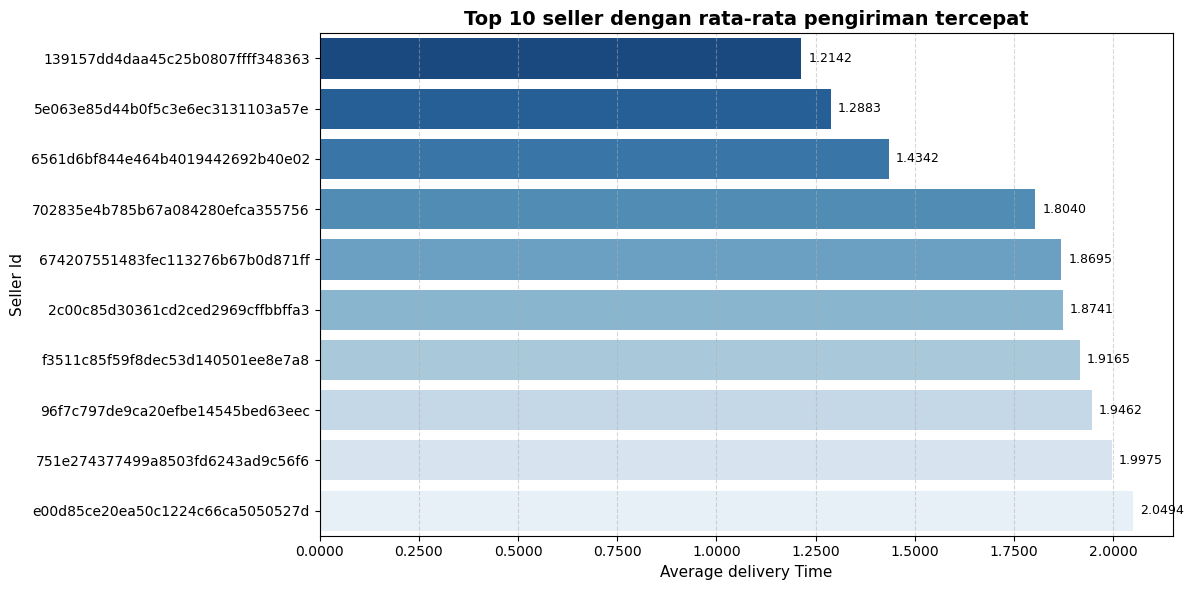

In [49]:
# 1. Ambil 10 data teratas (diurutkan dari terbesar)
# Sesuaikan 'Total Revenue' dan 'product_category_name' dengan nama kolom Anda
top_10_delivery = seller_delivery.sort_values(by='delivered_days', ascending=True).head(10)

# 2. Buat kanvas plot
plt.figure(figsize=(12, 6))

# 3. Membuat Horizontal Bar Plot
# (y = Nama Kategori, x = Nilai Angka)
ax = sns.barplot(
    data=top_10_delivery,
    x='delivered_days',            # Sumbu X (Angka)
    y='seller_id',   # Sumbu Y (Kategori)
    palette='Blues_r'            # Gradasi warna biru dari gelap ke terang (opsional)
)

# 4. Menambahkan Label Angka di Ujung Setiap Batang
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='{:,.4f}',               # Format koma pemisah ribuan
        padding=5,                   # Jarak teks dari batang
        fontsize=9
    )

# 5. Mengatasi format 1e6 pada sumbu X
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.4f}'))

# 6. Judul dan Label Sumbu
plt.title('Top 10 seller dengan rata-rata pengiriman tercepat', fontsize=14, fontweight='bold')
plt.xlabel('Average delivery Time', fontsize=11)
plt.ylabel('Seller Id', fontsize=11)

# Garis grid horizontal dibuang, cukup beri garis grid vertical di sumbu X
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout() # Agar layout tidak terpotong saat disimpan/ditampilkan
plt.show()

#### KEY INSIGHT

1. Seller dengan id `139157dd4daa45c25b0807ffff348363` memiliki waktu pengiriman tercepat dengan rata-rata pengiriman **1.2142** Hari
2. Seller dengan id `5e063e85d44b0f5c3e6ec3131103a57e` memiliki waktu pengiriman tercepat kedua dengan rata-rata pengiriman **1.2883** Hari
3. Perbedaan waktu pengiriman antar-seller menunjukkan adanya variasi dalam kecepatan pemenuhan dan pengiriman order, sehingga seller dengan waktu pengiriman lebih cepat dapat menjadi referensi untuk memahami praktik operasional yang mendukung proses fulfillment yang efisien.

## KEY FINDINGS

1. **Revenue antar-seller menunjukkan perbedaan nilai transaksi.** Seller dengan revenue tertinggi menghasilkan **226.987,93 dari 1.124 order**, sedangkan seller dengan revenue tertinggi kedua mencapai **217.940,44 hanya dari 348 order**. Hal ini menunjukkan bahwa jumlah order yang tinggi tidak selalu menghasilkan revenue tertinggi karena terdapat perbedaan nilai transaksi rata-rata antar-seller.

2. **Distribusi seller terkonsentrasi pada beberapa state.** State **SP memiliki jumlah seller terbanyak dengan 1.849 seller**, diikuti oleh **PR dengan 349 seller**, menunjukkan konsentrasi seller yang cukup besar pada state tertentu.

3. **Terdapat variasi waktu pengiriman antar-seller.** Seller dengan waktu pengiriman tercepat memiliki rata-rata **1,21 hari**, sedangkan seller tercepat kedua memiliki rata-rata **1,29 hari**. Perbedaan ini menunjukkan adanya variasi dalam kecepatan pemenuhan dan pengiriman order antar-seller.


## BUSINESS IMPLICATION

1. **Evaluasi seller berdasarkan revenue dan nilai transaksi secara bersamaan.** Seller dengan jumlah order tinggi belum tentu menghasilkan revenue tertinggi. Bisnis dapat memantau revenue, jumlah order, dan nilai transaksi rata-rata secara bersamaan untuk memahami perbedaan kontribusi masing-masing seller.

2. **Perkuat pengelolaan seller pada state dengan konsentrasi tinggi.** Tingginya jumlah seller di SP dan PR dapat menjadi pertimbangan dalam pengelolaan seller, monitoring performa, serta pengembangan strategi operasional pada wilayah dengan ekosistem seller yang lebih besar.

3. **Identifikasi praktik operasional dari seller dengan waktu pengiriman cepat.** Seller dengan rata-rata waktu pengiriman yang lebih cepat dapat dianalisis lebih lanjut untuk memahami pola operasional atau proses fulfillment yang mendukung kecepatan pengiriman, kemudian digunakan sebagai referensi untuk evaluasi seller lainnya.
